In [116]:
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import xr_utils

In [201]:
dirpath_self = Path().resolve()
dirpath_res_base = dirpath_root / 'exp_results'

exp_group = dirpath_self.name
exp_name = 'som'
exp_name_sub = 'exp_ou_nmean_10_nstd_10'

# Load batch result
dirpath_res = (dirpath_res_base / exp_group / exp_name
               / exp_name_sub / 'combined')
fpath_res = dirpath_res / 'rates_cvs_all.nc'
X = xr.load_dataset(fpath_res)
X

<xarray.Dataset> Size: 20kB
Dimensions:      (ou_mean_ind: 10, ou_std_ind: 10, pop: 6)
Coordinates:
  * ou_mean_ind  (ou_mean_ind) int32 40B 0 1 2 3 4 5 6 7 8 9
  * ou_std_ind   (ou_std_ind) int32 40B 0 1 2 3 4 5 6 7 8 9
  * pop          (pop) object 48B 'SOM2' 'SOM3' 'SOM4' 'SOM5A' 'SOM5B' 'SOM6'
Data variables:
    rate         (pop, ou_mean_ind, ou_std_ind) float64 5kB 0.0 0.0 ... 68.04
    cv           (pop, ou_mean_ind, ou_std_ind) float64 5kB nan nan ... 1.303
    v_med_max    (pop, ou_mean_ind, ou_std_ind) float64 5kB -204.8 ... -45.54
    v_med_min    (pop, ou_mean_ind, ou_std_ind) float64 5kB -224.0 ... -219.8
    ou_mean      (pop, ou_mean_ind) float64 480B -0.02 -0.01667 ... 0.01
    ou_std       (pop, ou_std_ind) float64 480B 0.0 0.002222 ... 0.01778 0.02

ou_mean = -0.0015
ou_std = 0.005


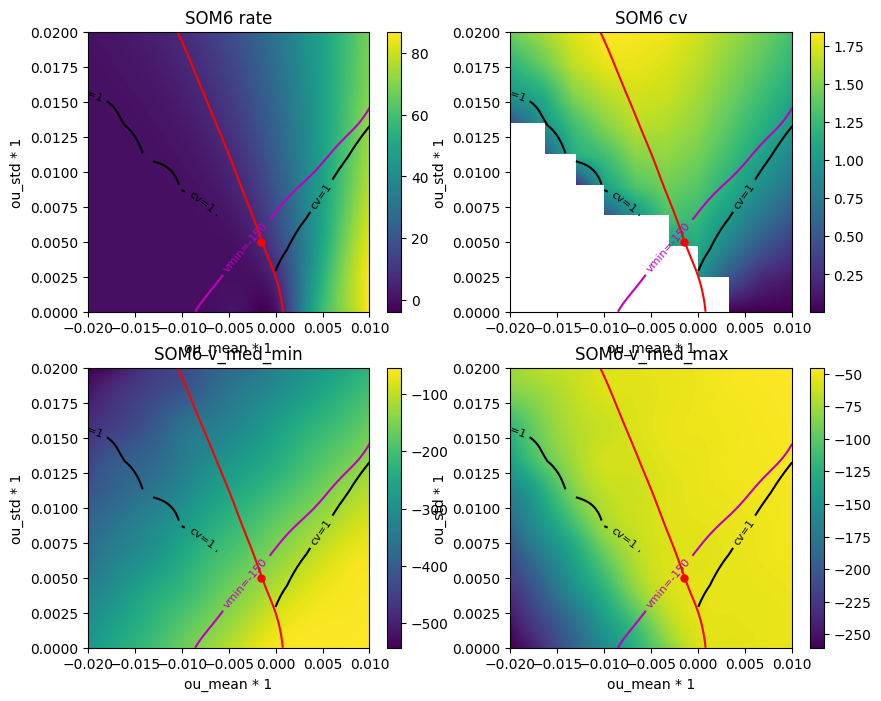

In [214]:
pop = 'SOM6'

# Load target rate
fpath_target = dirpath_self / exp_name / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')
r0 = df.loc[pop]['target_rate']

vars = ['rate', 'cv', 'v_med_min', 'v_med_max']
D = {}

# Extract variables, assign (ou_mean, ou_std) coords
for v in vars:
    X_ = X[v].sel(pop=pop)
    X_ = X_.rename(ou_mean_ind='ou_mean', ou_std_ind='ou_std')
    X_ = X_.assign_coords(
        ou_mean=X['ou_mean'].sel(pop=pop).values,
        ou_std=X['ou_std'].sel(pop=pop).values
    )
    D[v] = X_.T

# Upsample data
sz_new = 100
ou_mean = D['rate'].ou_mean.values
ou_std = D['rate'].ou_std.values
ou_mean_new = np.linspace(ou_mean.min(), ou_mean.max(), sz_new)
ou_std_new = np.linspace(ou_std.min(), ou_std.max(), sz_new)
for v, X_ in D.items():
    try:
        D[v] = X_.interp(ou_mean=ou_mean_new, ou_std=ou_std_new, method='cubic')
    except:
        D[v] = X_.interp(ou_mean=ou_mean_new, ou_std=ou_std_new, method='linear')

# Plot 2-d maps of r, cv, and v stats
fig = plt.figure(figsize=(10,8))
axes = []
for n, (v, X_) in enumerate(D.items()):
    ax = plt.subplot(2, 2, n + 1)
    axes.append(ax)
    xr_utils.plot_xr(X_, show_ax_names=True)
    cc = xr_utils.plot_xr_contour(D['rate'], '', [r0], colors=['r'])
    xr_utils.plot_xr_contour(D['cv'], 'cv', [1], colors=['k'])
    xr_utils.plot_xr_contour(D['v_med_min'], 'vmin', [-150], colors=['m'])
    plt.title(f'{pop} {v}')

# Selected point
ou_mean_sel = -0.0015
c = cc.allsegs[0][0]
ind = (np.abs(c[:, 0] - ou_mean_sel)).argmin()
ou_std_sel = c[ind, 1]
ou_std_sel = np.round(ou_std_sel, 3)
print(f'ou_mean = {ou_mean_sel}')
print(f'ou_std = {ou_std_sel}')
for ax in axes:
    ax.plot(ou_mean_sel, ou_std_sel, 'r.', markersize=10)

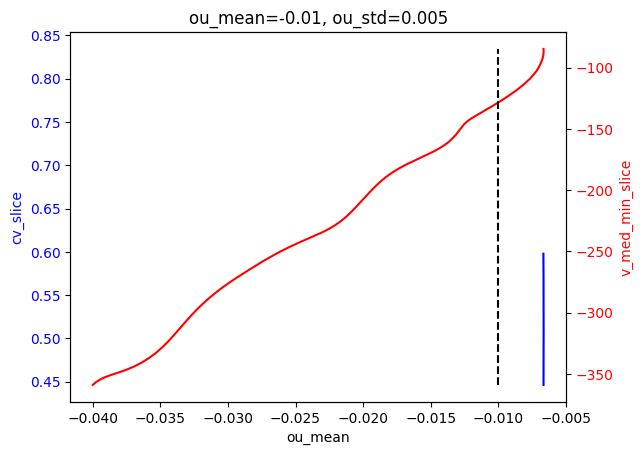

In [200]:
# Extract slice along the target rate contour for each var
Ds = {}
for v, X_ in D.items():
    Ds[f'{v}_slice'] = X_.interp(
        ou_std=('points', c[:, 1]),
        ou_mean=('points', c[:, 0])
    )

fig, ax1 = plt.subplots()

# Plot Ds['cv_slice'] on the first y-axis
ax1.plot(Ds['cv_slice'].ou_mean, Ds['cv_slice'], 'b-', label='cv_slice')
ax1.set_xlabel('ou_mean')
ax1.set_ylabel('cv_slice', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a second y-axis for Ds['v_med_min_slice']
ax2 = ax1.twinx()
ax2.plot(Ds['v_med_min_slice'].ou_mean, Ds['v_med_min_slice'], 'r-', label='v_med_min_slice')
ax2.set_ylabel('v_med_min_slice', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Plot a vertical line at ou_mean_sel on ax1
ax2.plot([ou_mean_sel, ou_mean_sel], [Ds['v_med_min_slice'].min(), Ds['v_med_min_slice'].max()], 'k--')

# Add a title
plt.title(f'ou_mean={ou_mean_sel:.04}, ou_std={ou_std_sel:.04}')

# Show the plot
plt.show()

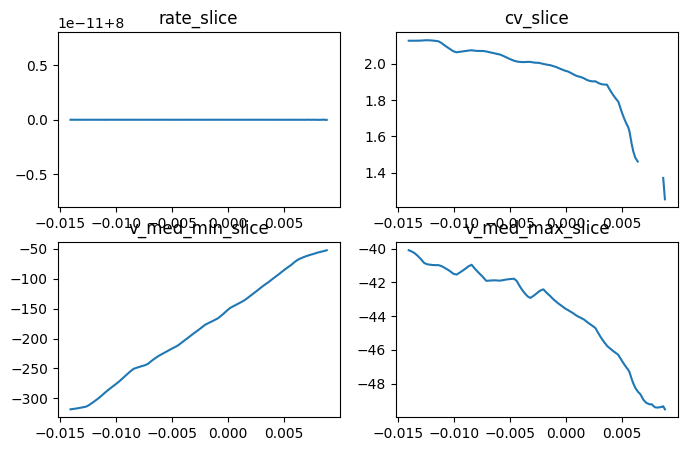

In [162]:
# Plot the slices
plt.figure(figsize=(8, 5))
for n, (v, X_) in enumerate(Ds.items()):
    plt.subplot(2, 2, n + 1)
    plt.plot(X_.ou_mean, X_)
    plt.title(v)

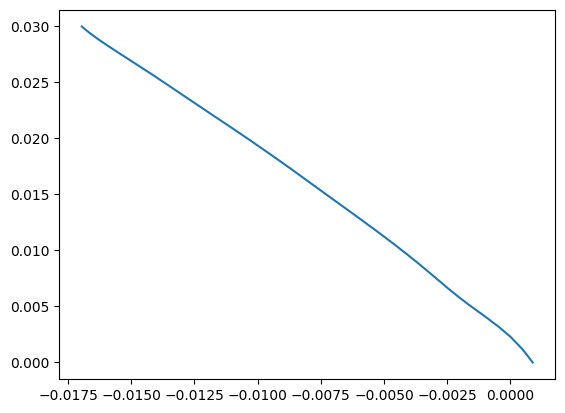

In [133]:
# Test rate contour
plt.figure()
for c in cc.allsegs[0]:
    plt.plot(c[:, 0], c[:, 1])